# 1. Chargement des données 

In [15]:
# Importer les librairies
import numpy as np
import pandas as pd 

In [16]:
# Charger les données 
path = "diabetes.csv"
data = pd.read_csv(path) 
data.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
430,2,99,0,0,0,22.2,0.108,23,0
182,1,0,74,20,23,27.7,0.299,21,0
691,13,158,114,0,0,42.3,0.257,44,1
126,3,120,70,30,135,42.9,0.452,30,0
545,8,186,90,35,225,34.5,0.423,37,1
727,0,141,84,26,0,32.4,0.433,22,0
108,3,83,58,31,18,34.3,0.336,25,0
605,1,124,60,32,0,35.8,0.514,21,0
445,0,180,78,63,14,59.4,2.420,25,1
328,2,102,86,36,120,45.5,0.127,23,1


In [17]:
# Verifier les données manquantes
data.isnull().sum() 

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# 2. Traitement des données

In [18]:
# Remplacer les valeurs manquantes par NaN
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
data[cols] = data[cols].replace(0, np.NaN)

# Remplacer les valeurs manquantes par la mediane de chaque colonne
data.fillna(data.median(), inplace=True)

# Separation des variables eexplicatives et les variables cibles
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# Diviser des données en ensembes d'entrainements et de tests
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# Normaliser les données 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)

# 3. Modélisation des données 

In [19]:
# Importer des modèles de classification 
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier 
from lightgbm import LGBMClassifier 
from sklearn.neural_network import MLPClassifier 

# Initialiser les modèles 
models = {
    "Logistic Regression" : LogisticRegression(),
    "Random Forest" : RandomForestClassifier(),
    "XGBoost" : XGBClassifier(),
    "LightGBM" : LGBMClassifier(),
    "MLP Classifier" : MLPClassifier(hidden_layer_sizes=[50,50,50], random_state=42)
    }
# Entrainement des modèles 
for name, model in models.items() :
    model.fit(X_train, y_train)
    print(f"{name} entrainé avec succès") 

Logistic Regression entrainé avec succès
Random Forest entrainé avec succès
XGBoost entrainé avec succès
[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000062 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 662
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

c:\Users\ajyes\anaconda3\envs\diabetes_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


# 4. Evaluation des modèles

In [20]:
# Importer les librairies
from sklearn.metrics import accuracy_score, precision_score, mean_squared_error, classification_report, roc_auc_score

# Créer une boucle pour evaluer les modèles
for name, model in models.items() :
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    print(f"Evaluation du modèle : {name}")
    print(f"Accuracy : {acc:.2f}") 
    print(f"Precision : {prec:.2f}")
    print(f"Mean Squared Error : {mse: .2f}")
    print(f"Classification Report : \n{report}")
    print(f"ROC AUC Score : {roc_auc:.2f}") 
    

Evaluation du modèle : Logistic Regression
Accuracy : 0.75
Precision : 0.67
Mean Squared Error :  0.25
Classification Report : 
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154

ROC AUC Score : 0.72
Evaluation du modèle : Random Forest
Accuracy : 0.75
Precision : 0.65
Mean Squared Error :  0.25
Classification Report : 
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        99
           1       0.65      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

ROC AUC Score : 0.73
Evaluation du modèle : XGBoost
Accuracy : 0.71
Precisi

c:\Users\ajyes\anaconda3\envs\diabetes_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# 5. Optimisation du modèle 

In [28]:
from sklearn.model_selection import GridSearchCV

# Définir les hyperparamètres à tester pour chaque modèle 
params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5]
}

grid = GridSearchCV(XGBClassifier(), params, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_model

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# 6. Interpretabilité avec Shap

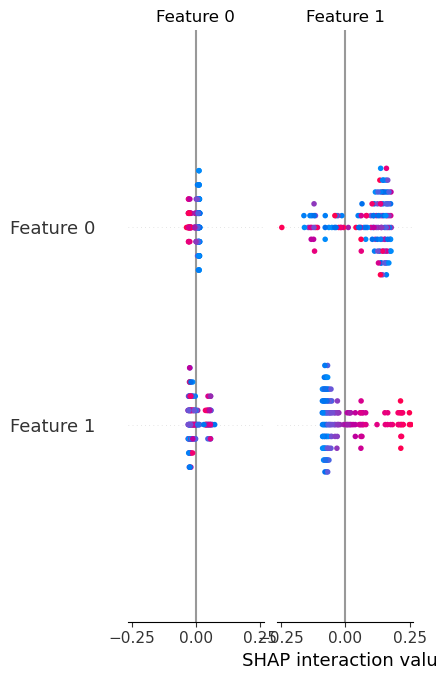

In [31]:
# Importer la librairies
import shap 

# Initialiser le modèle avec les meilleur paramètres 
model = RandomForestClassifier(n_estimators = 100,max_depth = 3)

# Entrainer le modèle
model.fit(X_train, y_train) 

# Initialiser l'explainer SHAP
explainer = shap.TreeExplainer(model)

# Calculer les valeurs SHAP pour les données de test
shap_values = explainer(X_test)

# Visualiser les valeurs SHAP
shap.summary_plot(shap_values, X_test) 


# 7. Sauvegarder le modèle 

In [34]:
# Importer la librairie 
import joblib 
# Sauvegarder le modèle entrainé
joblib.dump(model, "models/model.pkl")

# Sauvegarder le scaler
joblib.dump(scaler,"scalers/scaler.pkl")

['scalers/scaler.pkl']